In [1]:

from analysis import *

drop_cols = [
    "TWD","COG","TWA", "TimeUTC", "SecondsSince1970", "ISODateTimeUTC","Latitude","Longitude","Euler_X (deg)","Euler_Y (deg)",
    "Lat", "LatBow", "LatCenter", "LatStern", "Lon", "LonBow", "LonCenter", "LonStern",
    "Leg", "Log", "LogAlongCourse", "MagneticVariation", "Rank", "TimeLocal",
    "DistanceToLeader", "interval_id", "boat_name", "interval_duration",
    "Heel", "Heel_Lwd", "Line_R", "Line_L", "BelowLineCalc", "VMC","XTE","VMG","gain_forward","gain_lateral", "gain_vmg","Total_lines", "LoadCell_1","LoadCell_2","LoadCell_3","LoadCell_4","LoadCell_5","LoadCell_6","M_tot_X","M_tot_Y","M_front_X","M_front_Y","M_back_X","M_back_Y","P_front_X","P_front_Y","P_back_X","P_back_Y","Side_lines","total_line2","Line_R2","Line_L2","Line_C"
]
df = pd.read_csv("all_data.csv")
MAX_NULL_RATIO = 0.2

### II.1. All upwind data

In [2]:
upwind_data = df[df['TWA'] >= 0]
df_numeric_upwind = upwind_data.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_upwind.columns], inplace=True)
df_numeric_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_upwind)}")

Number of rows after filtering: 39432



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Removed features (> 20% NaN): ['boat_weight', 'load_cell']

Selected features (10): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'Line_C2', 'side_line2']

Data cleaning:
- Initial samples: 39432
- Removed samples with NaNs: 5682
- Final samples: 33750

Correlation with SOG:


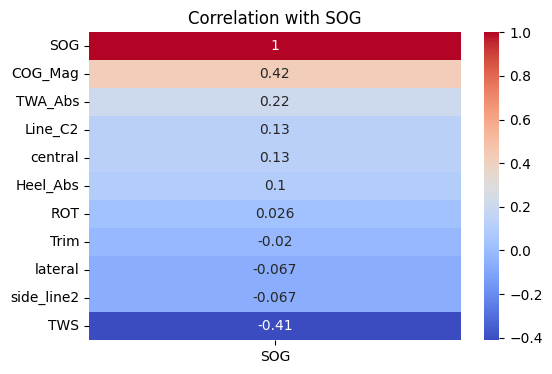


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,1706.509043,1.0,2466.163728,0.000000e+00,0.068113
TWS,846.072515,1.0,1222.702778,3.603013e-263,0.034971
TWA_Abs,567.351556,1.0,819.908828,3.448152e-178,0.023724
central,96.538569,1.0,139.512837,3.936397e-32,0.004118
Line_C2,96.538569,1.0,139.512837,3.936398e-32,0.004118
lateral,62.277411,1.0,90.000280,2.531637e-21,0.002660
side_line2,62.277411,1.0,90.000280,2.531637e-21,0.002660
Trim,14.192428,1.0,20.510205,5.951703e-06,0.000608
ROT,10.500640,1.0,15.175013,9.818045e-05,0.000450
Heel_Abs,6.346628,1.0,9.171838,2.459533e-03,0.000272



Polynomial fit:
R²: 0.248

Top coefficients:
   feature  coefficient
       TWS    -0.068724
   COG_Mag     0.018415
   TWA_Abs     0.014915
      Trim    -0.006370
side_line2    -0.005533
   lateral    -0.002766
  Heel_Abs    -0.002583
   Line_C2     0.001441
   central     0.001441
       ROT     0.000956


,feature,coefficient
0,TWS,-0.068724
2,COG_Mag,0.018415
7,TWA_Abs,0.014915
6,Trim,-0.006370
9,side_line2,-0.005533
4,lateral,-0.002766
3,Heel_Abs,-0.002583
8,Line_C2,0.001441
1,central,0.001441
5,ROT,0.000956


In [3]:
full_analysis(df_numeric_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

### II.2. Upwind: Gian vs Max
#### II.2.1. Upwind: Gian

In [4]:
Gian_data_upwind = upwind_data[(upwind_data['boat_name'] == "Gian Stragiotti")]
df_numeric_Gian_upwind = Gian_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Gian_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_Gian_upwind.columns], inplace=True)
df_numeric_Gian_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Gian_upwind)}")

Number of rows after filtering: 18287



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Removed features (> 20% NaN): ['boat_weight', 'load_cell']

Selected features (10): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'Line_C2', 'side_line2']

Data cleaning:
- Initial samples: 18287
- Removed samples with NaNs: 50
- Final samples: 18237

Correlation with SOG:


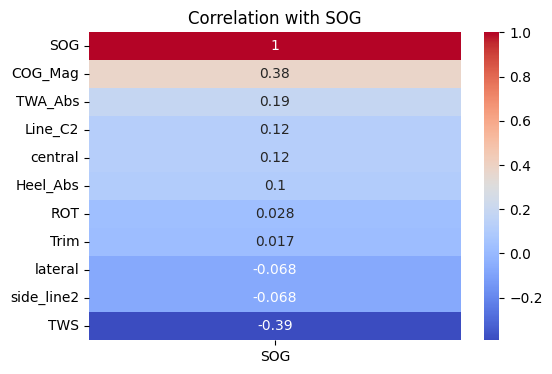


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,950.623248,1.0,1256.301043,3.584203e-266,0.064478
TWS,696.293020,1.0,920.189622,3.116092e-197,0.048056
side_line2,160.585212,1.0,212.222213,8.351495e-48,0.011509
lateral,160.585212,1.0,212.222213,8.351495e-48,0.011509
TWA_Abs,146.854962,1.0,194.076931,6.879253e-44,0.010535
Line_C2,116.228320,1.0,153.602134,3.919624e-35,0.008356
central,116.228320,1.0,153.602134,3.919625e-35,0.008356
Trim,21.618778,1.0,28.570407,9.143929e-08,0.001565
Heel_Abs,5.472994,1.0,7.232864,7.164607e-03,0.000397
ROT,3.674883,1.0,4.856561,2.755364e-02,0.000266



Polynomial fit:
R²: 0.229

Top coefficients:
   feature  coefficient
       TWS    -0.088183
side_line2    -0.025041
   COG_Mag     0.021075
   lateral    -0.012521
      Trim     0.011439
   TWA_Abs     0.010517
  Heel_Abs     0.003164
   Line_C2     0.002177
   central     0.002177
       ROT     0.000740


,feature,coefficient
0,TWS,-0.088183
9,side_line2,-0.025041
2,COG_Mag,0.021075
4,lateral,-0.012521
6,Trim,0.011439
7,TWA_Abs,0.010517
3,Heel_Abs,0.003164
8,Line_C2,0.002177
1,central,0.002177
5,ROT,0.000740


In [5]:
full_analysis(df_numeric_Gian_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.2.2. Upwind: max

In [6]:
Max_data_upwind = upwind_data[(upwind_data['boat_name'] == "Max Maeder")]
df_numeric_Max_upwind = Max_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Max_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_Max_upwind.columns], inplace=True)
df_numeric_Max_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Max_upwind)}")

Number of rows after filtering: 21145


In [7]:
Max_data_upwind.sample(10)

,ISODateTimeUTC,SecondsSince1970,SOG,TWA,TWS,TWD,BelowLineCalc,central,COG,COG_Mag,...,mast_brand,load_cell,gain_forward,gain_lateral,gain_vmg,Line_R2,Line_L2,Line_C2,side_line2,total_line2
30811,2025-11-26T14:13:24.145Z,1.764166e+09,22.7,45.700,15.000,346.700,NaN,107.1,301.0,298.0,...,Chub,2.0,-15.497276,-5.238296,-15.748247,7.500000,7.500000,107.1,15.000000,122.100000
8732,2025-11-26T12:38:03.660Z,1.764161e+09,22.6,24.770,16.162,329.070,NaN,110.1,304.3,301.3,...,Levi,2.0,-2.999330,0.893690,-2.364780,8.900000,8.900000,110.1,17.800000,127.900000
193,2025-11-25T13:48:06.556Z,1.764078e+09,22.5,24.979,20.546,286.379,NaN,72.7,261.4,258.4,...,Levi,2.0,6.691879,-0.946388,5.594229,9.550829,9.550829,72.7,19.101659,91.801659
46966,2025-11-27T08:10:49.065Z,1.764231e+09,23.1,31.074,14.393,350.674,NaN,123.0,319.6,316.6,...,NaN,NaN,4.002092,5.545804,6.645719,NaN,NaN,123.0,NaN,NaN
25346,2025-11-26T13:46:25.953Z,1.764165e+09,22.2,41.109,16.009,337.709,NaN,121.3,296.6,293.6,...,Levi,2.0,-11.928836,-2.508157,-11.686246,5.100000,5.100000,121.3,10.200000,131.500000
30832,2025-11-26T14:13:26.259Z,1.764166e+09,24.4,45.926,14.774,346.626,NaN,114.9,300.7,297.7,...,Chub,2.0,-13.421648,-6.648011,-14.821465,10.000000,10.000000,114.9,20.000000,134.900000
41310,2025-11-27T07:53:38.661Z,1.764230e+09,22.9,48.000,15.201,5.000,NaN,92.0,317.0,314.0,...,NaN,NaN,-3.823273,-2.190215,-4.320119,4.100000,4.100000,92.0,8.200000,100.200000
22417,2025-11-26T13:36:52.052Z,1.764164e+09,23.9,25.521,17.095,333.721,NaN,93.4,308.2,305.2,...,Levi,2.0,-0.829854,-12.569006,-6.256001,7.100000,7.100000,93.4,14.200000,107.600000
25243,2025-11-26T13:46:15.655Z,1.764165e+09,22.6,30.800,16.438,339.000,NaN,111.0,308.2,305.2,...,Levi,2.0,-8.206131,-0.466700,-7.540954,4.600000,4.600000,111.0,9.200000,120.200000
392,2025-11-25T13:48:26.456Z,1.764079e+09,20.6,27.191,20.737,288.191,NaN,113.3,261.0,258.0,...,Levi,2.0,5.580864,-0.893107,4.292065,12.300000,12.300000,113.3,24.600000,137.900000



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Removed features (> 20% NaN): ['lateral', 'boat_weight', 'load_cell', 'side_line2']

Selected features (8): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'ROT', 'Trim', 'TWA_Abs', 'Line_C2']

Data cleaning:
- Initial samples: 21145
- Removed samples with NaNs: 1916
- Final samples: 19229

Correlation with SOG:


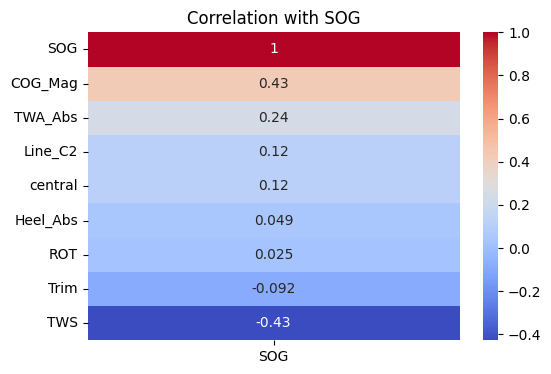


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,804.648278,1.0,1360.813639,6.983566e-288,0.066117
TWS,392.300210,1.0,663.454444,7.262178e-144,0.033365
TWA_Abs,308.842036,1.0,522.310761,4.398218e-114,0.026455
Trim,73.140695,1.0,123.694859,1.201629e-28,0.006394
Heel_Abs,50.925401,1.0,86.124562,1.864238e-20,0.004461
central,9.023650,1.0,15.260713,9.396453e-05,0.000793
Line_C2,9.023650,1.0,15.260713,9.396453e-05,0.000793
ROT,3.135451,1.0,5.302645,2.130370e-02,0.000276
Residual,11365.365630,19221.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.258

Top coefficients:
 feature  coefficient
     TWS    -0.062938
    Trim    -0.018345
 COG_Mag     0.016163
 TWA_Abs     0.015017
Heel_Abs    -0.010332
     ROT     0.000725
 central     0.000570
 Line_C2     0.000570


,feature,coefficient
0,TWS,-0.062938
5,Trim,-0.018345
2,COG_Mag,0.016163
6,TWA_Abs,0.015017
3,Heel_Abs,-0.010332
4,ROT,0.000725
1,central,0.000570
7,Line_C2,0.000570


In [8]:
full_analysis(df_numeric_Max_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.2.3. Upwind: max vs Gian t_test

In [9]:
t_test(df_numeric_Gian_upwind,df_numeric_Max_upwind)

T-statistic: 24.875, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


### II.3. Upwind: Master vs Slave
#### II.3.1. Master

In [10]:
master_data_upwind = upwind_data[upwind_data['boat_role'] == "master"]
df_numeric_master_upwind = master_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_master_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_master_upwind.columns], inplace=True)
df_numeric_master_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_master_upwind)}")

Number of rows after filtering: 12790



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Selected features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Data cleaning:
- Initial samples: 12790
- Removed samples with NaNs: 675
- Final samples: 12115

Correlation with SOG:


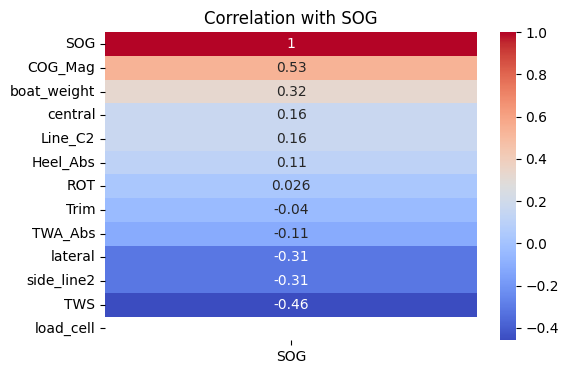


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,978.075509,1.0,1732.578247,0.000000e+00,0.125208
TWS,154.962727,1.0,274.503398,5.547709e-61,0.022174
lateral,105.510306,1.0,186.902605,3.103887e-42,0.015205
side_line2,105.510306,1.0,186.902605,3.103887e-42,0.015205
central,64.735917,1.0,114.674216,1.220554e-26,0.009384
Line_C2,64.735917,1.0,114.674216,1.220554e-26,0.009384
boat_weight,60.757552,1.0,107.626877,4.133837e-25,0.008813
Trim,19.878029,1.0,35.212252,3.037471e-09,0.002900
load_cell,19.198107,1.0,34.007826,5.629318e-09,0.002802
TWA_Abs,14.754070,1.0,26.135590,3.231216e-07,0.002154



Polynomial fit:
R²: 0.396

Top coefficients:
    feature  coefficient
boat_weight     0.343643
        TWS    -0.051537
    COG_Mag     0.022797
 side_line2    -0.020038
       Trim    -0.012045
    lateral    -0.010019
    TWA_Abs     0.006884
   Heel_Abs    -0.003921
    central     0.001971
    Line_C2     0.001971


,feature,coefficient
8,boat_weight,0.343643
0,TWS,-0.051537
2,COG_Mag,0.022797
11,side_line2,-0.020038
6,Trim,-0.012045
4,lateral,-0.010019
7,TWA_Abs,0.006884
3,Heel_Abs,-0.003921
1,central,0.001971
10,Line_C2,0.001971


In [11]:
full_analysis(df_numeric_master_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### II.3.2 Slave

In [12]:
slave_data_upwind = upwind_data[upwind_data['boat_role'] == "slave"]
df_numeric_slave_upwind = slave_data_upwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_slave_upwind.drop(columns=[c for c in drop_cols if c in df_numeric_slave_upwind.columns], inplace=True)
df_numeric_slave_upwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_slave_upwind)}")

Number of rows after filtering: 26642



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Removed features (> 20% NaN): ['boat_weight', 'load_cell']

Selected features (10): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'Line_C2', 'side_line2']

Data cleaning:
- Initial samples: 26642
- Removed samples with NaNs: 5007
- Final samples: 21635

Correlation with SOG:


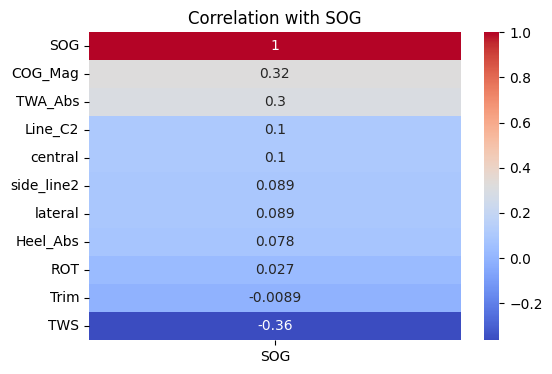


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
TWA_Abs,709.213665,1.0,1000.570313,1.038755e-214,0.044221
COG_Mag,521.076317,1.0,735.143046,3.122017e-159,0.032876
TWS,503.891399,1.0,710.898280,3.943000e-154,0.031826
side_line2,128.706597,1.0,181.581386,3.210503e-41,0.008327
lateral,128.706597,1.0,181.581386,3.210503e-41,0.008327
ROT,16.853896,1.0,23.777755,1.088923e-06,0.001098
central,14.312919,1.0,20.192902,7.037509e-06,0.000933
Line_C2,14.312919,1.0,20.192901,7.037510e-06,0.000933
Trim,3.997284,1.0,5.639434,1.756955e-02,0.000261
Heel_Abs,0.028023,1.0,0.039536,8.423934e-01,0.000002



Polynomial fit:
R²: 0.206

Top coefficients:
   feature  coefficient
       TWS    -0.065676
   TWA_Abs     0.019005
   COG_Mag     0.014294
side_line2     0.010208
   lateral     0.005104
      Trim     0.004377
       ROT     0.001548
   central     0.000709
   Line_C2     0.000709
  Heel_Abs    -0.000221


,feature,coefficient
0,TWS,-0.065676
7,TWA_Abs,0.019005
2,COG_Mag,0.014294
9,side_line2,0.010208
4,lateral,0.005104
6,Trim,0.004377
5,ROT,0.001548
1,central,0.000709
8,Line_C2,0.000709
3,Heel_Abs,-0.000221


In [13]:
full_analysis(df_numeric_slave_upwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.3. Upwind: Master vs Slave t_test

In [14]:
t_test(df_numeric_master_upwind,df_numeric_slave_upwind)

T-statistic: -19.376, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


## III Downwind
### III.1. All downwind data

In [15]:
downwind_data = df[df['TWA'] < 0]
df_numeric_downwind = downwind_data.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_downwind.columns], inplace=True)
df_numeric_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_downwind)}")

Number of rows after filtering: 25115



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Removed features (> 20% NaN): ['boat_weight', 'load_cell']

Selected features (10): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'Line_C2', 'side_line2']

Data cleaning:
- Initial samples: 25115
- Removed samples with NaNs: 2815
- Final samples: 22300

Correlation with SOG:


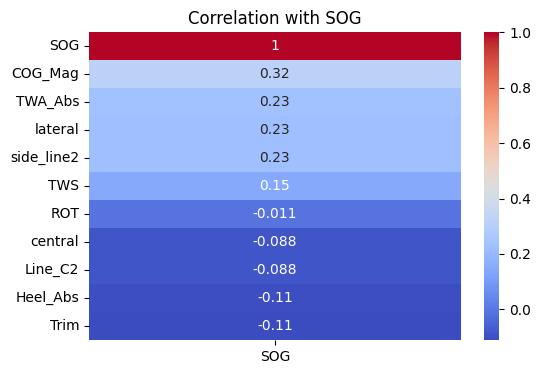


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,4820.120817,1.0,2772.317385,0.000000e+00,0.110613
side_line2,3259.069808,1.0,1874.470835,0.000000e+00,0.077568
lateral,3259.069808,1.0,1874.470835,0.000000e+00,0.077568
TWA_Abs,569.594602,1.0,327.605278,1.059783e-72,0.014484
TWS,505.214520,1.0,290.576741,9.581166e-65,0.012868
Heel_Abs,278.034883,1.0,159.913199,1.578062e-36,0.007123
central,9.011371,1.0,5.182936,2.281918e-02,0.000232
Line_C2,9.011371,1.0,5.182936,2.281918e-02,0.000232
Trim,6.310329,1.0,3.629418,5.677951e-02,0.000163
ROT,3.022166,1.0,1.738214,1.873788e-01,0.000078



Polynomial fit:
R²: 0.228

Top coefficients:
   feature  coefficient
       TWS     0.079693
   COG_Mag     0.061622
side_line2     0.060741
   lateral     0.030371
   TWA_Abs     0.023693
  Heel_Abs    -0.023294
      Trim    -0.005760
   central     0.001084
   Line_C2     0.001084
       ROT    -0.001067


,feature,coefficient
0,TWS,0.079693
2,COG_Mag,0.061622
9,side_line2,0.060741
4,lateral,0.030371
7,TWA_Abs,0.023693
3,Heel_Abs,-0.023294
6,Trim,-0.005760
1,central,0.001084
8,Line_C2,0.001084
5,ROT,-0.001067


In [16]:

full_analysis(df_numeric_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

### III.2. Downwind: Gian vs max
#### III.2.1. Downwind: Gian

In [17]:
gian_data_downwind = downwind_data[
    (downwind_data['boat_name'] == "Gian Stragiotti") |
    ((downwind_data['boat_name'] == "SenseBoard") & (downwind_data['opponent_name'] == "max Maeder"))
]
df_numeric_gian_downwind = gian_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_gian_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_gian_downwind.columns], inplace=True)
df_numeric_gian_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_gian_downwind)}")

Number of rows after filtering: 12453



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Removed features (> 20% NaN): ['boat_weight', 'load_cell']

Selected features (10): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'Line_C2', 'side_line2']

Data cleaning:
- Initial samples: 12453
- Removed samples with NaNs: 40
- Final samples: 12413

Correlation with SOG:


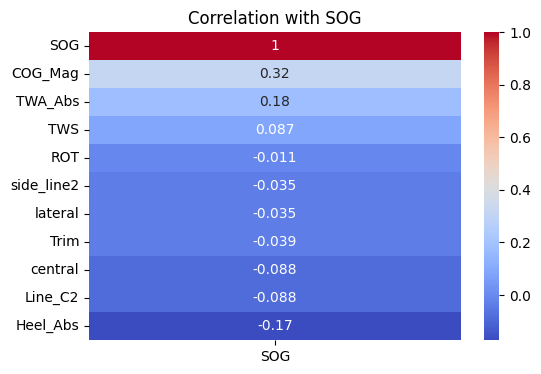


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,2975.416534,1.0,1444.072300,5.238343e-299,0.104280
Heel_Abs,720.297996,1.0,349.585469,5.935689e-77,0.027411
Line_C2,298.112425,1.0,144.684245,3.848790e-33,0.011530
central,298.112425,1.0,144.684245,3.848790e-33,0.011530
TWS,228.434959,1.0,110.867367,8.129044e-26,0.008859
TWA_Abs,165.041565,1.0,80.100366,4.060662e-19,0.006416
Trim,81.469398,1.0,39.539910,3.322127e-10,0.003178
side_line2,50.248237,1.0,24.387203,7.981636e-07,0.001962
lateral,50.248237,1.0,24.387203,7.981636e-07,0.001962
ROT,0.201694,1.0,0.097889,7.543832e-01,0.000008



Polynomial fit:
R²: 0.157

Top coefficients:
   feature  coefficient
       TWS     0.073623
   COG_Mag     0.062008
  Heel_Abs    -0.051445
side_line2    -0.028163
      Trim     0.026967
   TWA_Abs     0.017162
   lateral    -0.014082
   Line_C2     0.008969
   central     0.008969
       ROT    -0.000362


,feature,coefficient
0,TWS,0.073623
2,COG_Mag,0.062008
3,Heel_Abs,-0.051445
9,side_line2,-0.028163
6,Trim,0.026967
7,TWA_Abs,0.017162
4,lateral,-0.014082
8,Line_C2,0.008969
1,central,0.008969
5,ROT,-0.000362


In [18]:

full_analysis(df_numeric_gian_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.2.2. Downwind: max

In [19]:
Max_data_downwind = downwind_data[
    (downwind_data['boat_name'] == "Max Maeder") |
    ((downwind_data['boat_name'] == "SenseBoard") & (downwind_data['opponent_name'] == "Gian Stragiotti"))
]
df_numeric_Max_downwind = Max_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_Max_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_Max_downwind.columns], inplace=True)
df_numeric_Max_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_Max_downwind)}")

Number of rows after filtering: 12662



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Removed features (> 20% NaN): ['lateral', 'boat_weight', 'load_cell', 'side_line2']

Selected features (8): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'ROT', 'Trim', 'TWA_Abs', 'Line_C2']

Data cleaning:
- Initial samples: 12662
- Removed samples with NaNs: 300
- Final samples: 12362

Correlation with SOG:


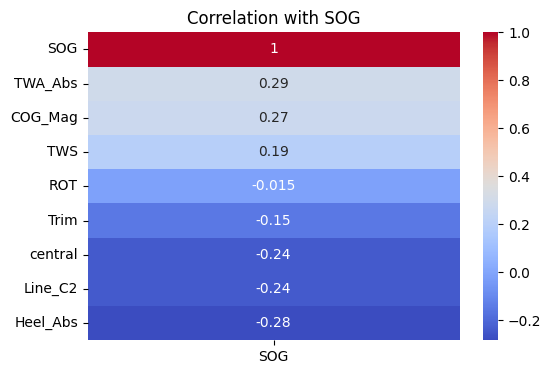


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,799.804611,1.0,607.396404,5.825139e-131,0.046862
TWA_Abs,622.177105,1.0,472.500573,7.642490e-103,0.036838
Trim,254.610677,1.0,193.359237,1.252201e-43,0.015410
TWS,208.052348,1.0,158.001400,5.136110e-36,0.012628
Heel_Abs,70.507705,1.0,53.545736,2.682643e-13,0.004316
central,44.721272,1.0,33.962719,5.758056e-09,0.002742
Line_C2,44.721271,1.0,33.962719,5.758056e-09,0.002742
ROT,6.632626,1.0,5.037022,2.482874e-02,0.000408
Residual,16267.442636,12354.0,NaN,NaN,0.500000



Polynomial fit:
R²: 0.200

Top coefficients:
 feature  coefficient
     TWS     0.071697
    Trim    -0.052841
 COG_Mag     0.036161
 TWA_Abs     0.034040
Heel_Abs    -0.016828
 central    -0.003120
 Line_C2    -0.003120
     ROT     0.002196


,feature,coefficient
0,TWS,0.071697
5,Trim,-0.052841
2,COG_Mag,0.036161
6,TWA_Abs,0.034040
3,Heel_Abs,-0.016828
1,central,-0.003120
7,Line_C2,-0.003120
4,ROT,0.002196


In [20]:
full_analysis(df_numeric_Max_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.2.3. Downwind: Max vs Gian t_test

In [21]:
t_test(df_numeric_Max_downwind,df_numeric_gian_downwind)

T-statistic: 37.750, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.


### III.3. Downwind: Master vs Slave
#### III.3.1 Downwind Master

In [22]:
master_data_downwind = downwind_data[downwind_data['boat_role'] == "master"]
df_numeric_master_downwind = master_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_master_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_master_downwind.columns], inplace=True)
df_numeric_master_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_master_downwind)}")

Number of rows after filtering: 7450



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Selected features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Data cleaning:
- Initial samples: 7450
- Removed samples with NaNs: 316
- Final samples: 7134

Correlation with SOG:


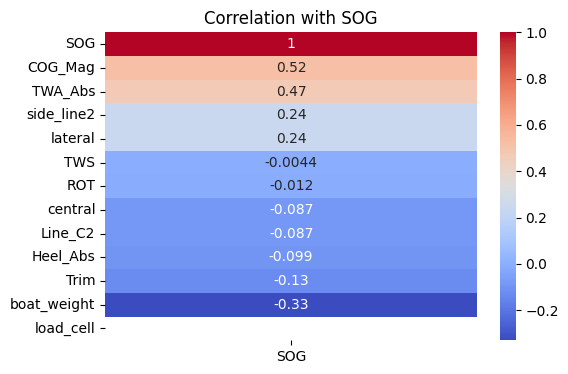


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
load_cell,807.156858,1.0,591.013716,1.745568e-125,0.076606
boat_weight,722.327056,1.0,528.899920,5.877728e-113,0.069111
COG_Mag,495.349822,1.0,362.703403,6.472855e-79,0.048446
TWA_Abs,215.319903,1.0,157.660825,8.766507e-36,0.021652
Heel_Abs,208.955927,1.0,153.001015,8.697492e-35,0.021025
central,183.715211,1.0,134.519342,7.948442e-31,0.018533
Line_C2,183.715211,1.0,134.519342,7.948442e-31,0.018533
TWS,174.251273,1.0,127.589689,2.448858e-29,0.017595
side_line2,109.582896,1.0,80.238424,4.175921e-19,0.011138
lateral,109.582896,1.0,80.238424,4.175921e-19,0.011138



Polynomial fit:
R²: 0.410

Top coefficients:
    feature  coefficient
boat_weight    -1.931549
        TWS    -0.102236
    COG_Mag     0.093145
    TWA_Abs     0.050425
 side_line2    -0.040930
   Heel_Abs    -0.036739
    lateral    -0.020465
    Line_C2     0.008583
    central     0.008583
        ROT    -0.004645


,feature,coefficient
8,boat_weight,-1.931549
0,TWS,-0.102236
2,COG_Mag,0.093145
7,TWA_Abs,0.050425
11,side_line2,-0.040930
3,Heel_Abs,-0.036739
4,lateral,-0.020465
10,Line_C2,0.008583
1,central,0.008583
5,ROT,-0.004645


In [23]:
full_analysis(df_numeric_master_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.2 Downwind Slave

In [24]:
slave_data_downwind = downwind_data[downwind_data['boat_role'] == "slave"]
df_numeric_slave_downwind = slave_data_downwind.select_dtypes(include=["float64", "int64"]).copy()
df_numeric_slave_downwind.drop(columns=[c for c in drop_cols if c in df_numeric_slave_downwind.columns], inplace=True)
df_numeric_slave_downwind.dropna(subset=["SOG"], inplace=True)
print(f"Number of rows after filtering: {len(df_numeric_slave_downwind)}")

Number of rows after filtering: 17665



Initial features (12): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'boat_weight', 'load_cell', 'Line_C2', 'side_line2']

Removed features (> 20% NaN): ['boat_weight', 'load_cell']

Selected features (10): ['TWS', 'central', 'COG_Mag', 'Heel_Abs', 'lateral', 'ROT', 'Trim', 'TWA_Abs', 'Line_C2', 'side_line2']

Data cleaning:
- Initial samples: 17665
- Removed samples with NaNs: 2499
- Final samples: 15166

Correlation with SOG:


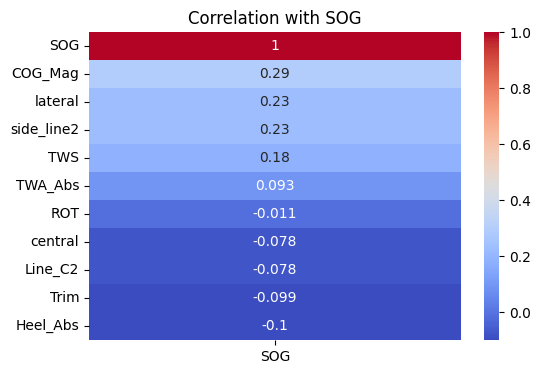


ANOVA:


,sum_sq,df,F,PR(>F),partial_eta_sq
COG_Mag,3838.609790,1.0,2252.826792,0.000000e+00,1.293997e-01
lateral,2064.461352,1.0,1211.603705,1.849029e-255,7.401998e-02
side_line2,2064.461352,1.0,1211.603705,1.849029e-255,7.401998e-02
TWS,800.800066,1.0,469.978441,1.167722e-102,3.007481e-02
Heel_Abs,223.359750,1.0,131.086736,3.155260e-30,8.574437e-03
TWA_Abs,16.858750,1.0,9.894167,1.661241e-03,6.523528e-04
Line_C2,4.887879,1.0,2.868629,9.034235e-02,1.892252e-04
central,4.887879,1.0,2.868629,9.034235e-02,1.892252e-04
Trim,0.338558,1.0,0.198695,6.557828e-01,1.310894e-05
ROT,0.025531,1.0,0.014984,9.025769e-01,9.885789e-07



Polynomial fit:
R²: 0.218

Top coefficients:
   feature  coefficient
       TWS     0.120734
   COG_Mag     0.059861
side_line2     0.057562
   lateral     0.028781
  Heel_Abs    -0.025479
   TWA_Abs     0.004758
      Trim    -0.001640
   central     0.000991
   Line_C2     0.000991
       ROT     0.000121


,feature,coefficient
0,TWS,0.120734
2,COG_Mag,0.059861
9,side_line2,0.057562
4,lateral,0.028781
3,Heel_Abs,-0.025479
7,TWA_Abs,0.004758
6,Trim,-0.001640
1,central,0.000991
8,Line_C2,0.000991
5,ROT,0.000121


In [25]:
full_analysis(df_numeric_slave_downwind, target_variable="SOG", max_null_ratio=MAX_NULL_RATIO)

#### III.3.3. Downwind: Master vs Slave t_test

In [26]:
t_test(df_numeric_master_downwind,df_numeric_slave_downwind)

T-statistic: 18.021, p-value: 0.000000000000000
The difference is statistically significant, keeping data split.
